# Chapter 11 — Vision Transformers

Chapter 10 ended with a claim that sounds too good: the encoder block you built
is *already* a Vision Transformer, and turning it into one requires changing
nothing inside it. This chapter cashes that claim in.

The entire idea of ViT (Dosovitskiy et al., 2020, *"An Image is Worth 16×16
Words"*) is a **change of input representation**:

> Cut the image into a grid of fixed-size patches. Flatten each patch. Project
> each one through a single linear layer. Now you have a sequence of vectors, so
> feed it to a Transformer exactly as if the patches were words.

That is it. No convolutions in the body, no image-specific machinery, no changes
to attention. The paper's own summary is that a standard Transformer applied
directly to image patches "performs very well" when pre-trained on enough data.

**That last clause is doing an enormous amount of work, and we are going to
measure exactly how much.** In Module 4 we train this ViT against a plain CNN on
CIFAR-10 at matched parameter count, and the CNN wins by a wide margin. That is
not a bug in our implementation. It is the single most important practical fact
about Vision Transformers, and the reason the paper needed 300 million images.

| Module | What you build | Dataset (Hugging Face) |
|---|---|---|
| 1 | **Patch embedding**: image → sequence, and why a `Conv2d` *is* the linear projection | `uoft-cs/cifar10` |
| 2 | The **`[CLS]` token** and **learnable** positional embeddings | — |
| 3 | The full ViT, assembled from Chapter 10's block unchanged | — |
| 4 | ViT vs CNN, ± augmentation: the **inductive bias** experiment | `uoft-cs/cifar10` |
| 5 | What the ViT learned: positional structure and attention distance | — |

> 🧠 **The intuition:** the idea in plain language, no symbols.
> 📐 **The math:** the same idea written precisely, so you can read papers.
> 💻 **The code:** the same idea again, executable, in the cell that follows.

**Runtime:** ~7 minutes on a GPU, for four training runs of 30 epochs over all
50,000 CIFAR-10 images. CIFAR-10 is already cached from Chapter 2. On CPU, drop
`EPOCHS` to 5 and expect proportionally weaker numbers from every model.


In [1]:
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset

torch.manual_seed(42)
plt.rcParams["figure.figsize"] = (7, 4.5)
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cudnn.benchmark = True

print("PyTorch", torch.__version__, "| device:", device)

/home/mujtaba/venvs/datasci/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch 2.11.0+cu128 | device: cuda


---
# Module 1 — Patch Embedding: An Image as a Sentence

## 1.1 Why patches and not pixels

🧠 **The intuition.** The obvious way to feed an image to a Transformer is to
treat every pixel as a token. Chapter 9, Module 6 already told us why that
fails: attention is $O(n^2)$ in sequence length, and a 224×224 image has 50,176
pixels.

Patches solve it. Cut the image into a grid of $P \times P$ squares, flatten
each into a vector, and treat the grid as a sequence. A 16×16 patch size turns
those 50,176 tokens into 196, a **65,000×** reduction in the size of the
attention matrix.

There is a second, quieter reason. A single pixel carries almost no information;
it is the wrong unit of meaning, in the way a single letter is the wrong unit for
language. A 16×16 patch is closer to a word: big enough to contain an edge, a
texture, a corner.

📐 **The math.** Reshape $x \in \mathbb{R}^{H \times W \times C}$ into a
sequence of flattened patches:

$$ x_p \in \mathbb{R}^{N \times (P^2 \cdot C)}, \qquad N = \frac{HW}{P^2} $$

then project each into the model width with **one shared** matrix $E \in
\mathbb{R}^{(P^2 C) \times d}$. Shared across patches, so the same $E$ applies at
every spatial location, which is the one piece of translation-related structure
a ViT retains.

💻 **The code.** CIFAR-10 is 32×32, so we use $P = 4$, giving $8 \times 8 = 64$
patches. Load the data first.


In [2]:
cifar = load_dataset("uoft-cs/cifar10")
class_names = cifar["train"].features["label"].names
print(class_names)


def to_tensors(split, n=None):
    ds = split.shuffle(seed=42)
    if n is not None:
        ds = ds.select(range(n))
    imgs = np.stack([np.array(im) for im in ds["img"]])           # (N, 32, 32, 3)
    x = torch.tensor(imgs).permute(0, 3, 1, 2).float() / 255.0    # -> (N, 3, 32, 32)
    return x, torch.tensor(list(ds["label"]))


X_train, y_train = to_tensors(cifar["train"])
X_test, y_test = to_tensors(cifar["test"])

MEAN = X_train.mean(dim=(0, 2, 3))[None, :, None, None]
STD = X_train.std(dim=(0, 2, 3))[None, :, None, None]
X_train = (X_train - MEAN) / STD
X_test = (X_test - MEAN) / STD

print("train:", tuple(X_train.shape), "| test:", tuple(X_test.shape))
print("channels-first (N, C, H, W): PyTorch's convention, unlike Keras's (N, H, W, C)")

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


train: (50000, 3, 32, 32) | test: (10000, 3, 32, 32)
channels-first (N, C, H, W): PyTorch's convention, unlike Keras's (N, H, W, C)


In [3]:
IMG_SIZE, PATCH = 32, 4
N_PATCHES = (IMG_SIZE // PATCH) ** 2
GRID = IMG_SIZE // PATCH

print(f"{IMG_SIZE}x{IMG_SIZE} image, {PATCH}x{PATCH} patches "
      f"-> {GRID}x{GRID} grid = {N_PATCHES} tokens")
print(f"each patch flattens to {PATCH * PATCH * 3} numbers")
print(f"\nattention matrix: {N_PATCHES}² = {N_PATCHES ** 2:,} entries")
print(f"if we used pixels: {IMG_SIZE * IMG_SIZE}² = {(IMG_SIZE * IMG_SIZE) ** 2:,} entries "
      f"({(IMG_SIZE * IMG_SIZE) ** 2 / N_PATCHES ** 2:.0f}x more)")

32x32 image, 4x4 patches -> 8x8 grid = 64 tokens
each patch flattens to 48 numbers

attention matrix: 64² = 4,096 entries
if we used pixels: 1024² = 1,048,576 entries (256x more)


💻 **See the cut.** Nothing is learned here: this is a `reshape` with the axes
in the right order.


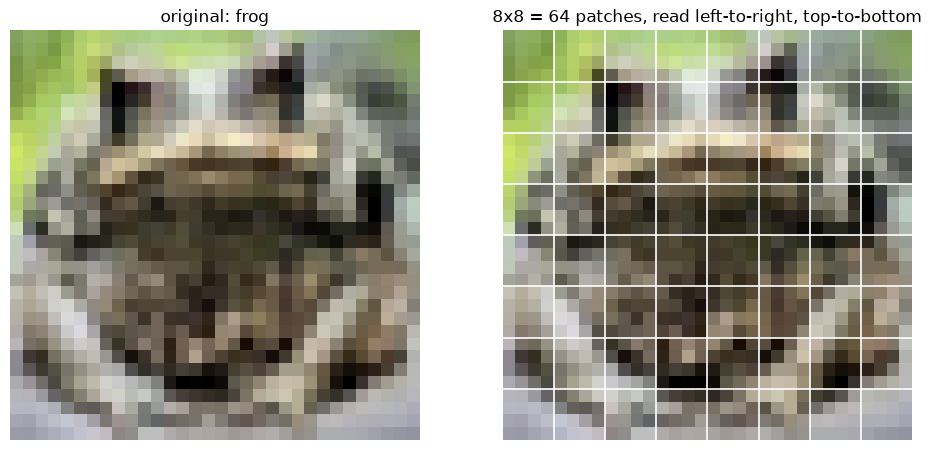

patchify: (4, 3, 32, 32) -> (4, 64, 48)
            (B, C, H, W)         (B, sequence length, features per token)

That second shape is exactly what Chapter 10's encoder block expects.


In [4]:
def patchify(x, patch=PATCH):
    '''(B, C, H, W) -> (B, N, patch*patch*C). Pure reshaping, no parameters.'''
    B, Cc, H, W = x.shape
    x = x.unfold(2, patch, patch).unfold(3, patch, patch)     # (B, C, gh, gw, p, p)
    x = x.permute(0, 2, 3, 1, 4, 5)                           # (B, gh, gw, C, p, p)
    return x.reshape(B, -1, Cc * patch * patch)               # (B, N, p*p*C)


def show_patched(idx):
    img = (X_train[idx] * STD[0] + MEAN[0]).permute(1, 2, 0).numpy().clip(0, 1)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))

    axes[0].imshow(img)
    axes[0].set_title(f"original: {class_names[y_train[idx]]}")
    axes[0].axis("off")

    axes[1].imshow(img)
    for k in range(1, GRID):
        axes[1].axhline(k * PATCH - 0.5, color="white", lw=1.2)
        axes[1].axvline(k * PATCH - 0.5, color="white", lw=1.2)
    axes[1].set_title(f"{GRID}x{GRID} = {N_PATCHES} patches, read left-to-right, top-to-bottom")
    axes[1].axis("off")
    plt.tight_layout(); plt.show()


show_patched(7)

seq = patchify(X_train[:4])
print("patchify:", tuple(X_train[:4].shape), "->", tuple(seq.shape))
print("            (B, C, H, W)         (B, sequence length, features per token)")
print("\nThat second shape is exactly what Chapter 10's encoder block expects.")

## 1.2 The `Conv2d` trick

🧠 **The intuition.** Every ViT implementation you will read, including the
official one and `timm`'s, does the patch embedding with a **convolution**
rather than a reshape-then-linear:

```python
nn.Conv2d(in_channels=3, out_channels=d_model, kernel_size=P, stride=P)
```

This looks like a contradiction ("the whole point was to get rid of
convolutions"), and it is not one. A convolution whose **kernel size equals its
stride** never overlaps itself: each output position sees exactly one patch, with
no reuse of pixels between neighbours. Applying a $P \times P \times C$ kernel to
a non-overlapping patch *is* a dot product between the flattened patch and the
flattened kernel, which is exactly one row of the linear projection $E$.

So it is the same operation, expressed in a form that cuDNN has spent a decade
optimizing. Which is genuinely worth knowing, because "why is there a Conv2d in
my convolution-free architecture" is a question that trips up nearly everyone
reading ViT source for the first time.

💻 **Do not take it on trust.** Build both, share the weights, and compare.


In [5]:
D_MODEL = 192

conv_embed = nn.Conv2d(3, D_MODEL, kernel_size=PATCH, stride=PATCH)
linear_embed = nn.Linear(PATCH * PATCH * 3, D_MODEL)

# Copy the conv kernel into the linear layer. The conv kernel has shape
# (d_model, C, P, P); our patchify() lays each token out as (C, P, P) flattened
# in that same order, so a plain reshape lines them up.
with torch.no_grad():
    linear_embed.weight.copy_(conv_embed.weight.reshape(D_MODEL, -1))
    linear_embed.bias.copy_(conv_embed.bias)

batch = X_train[:8]

via_conv = conv_embed(batch).flatten(2).transpose(1, 2)      # (B, d, gh, gw) -> (B, N, d)
via_linear = linear_embed(patchify(batch))                   # (B, N, p*p*C) -> (B, N, d)

print("via Conv2d(k=P, stride=P) :", tuple(via_conv.shape))
print("via reshape + Linear      :", tuple(via_linear.shape))
print(f"max absolute difference   : {(via_conv - via_linear).abs().max().item():.2e}")
assert torch.allclose(via_conv, via_linear, atol=1e-5)
print("\n✓ identical. The Conv2d in every ViT is a linear patch projection wearing a hat.")

via Conv2d(k=P, stride=P) : (8, 64, 192)
via reshape + Linear      : (8, 64, 192)
max absolute difference   : 9.54e-07

✓ identical. The Conv2d in every ViT is a linear patch projection wearing a hat.


---
# Module 2 — The `[CLS]` Token and Learnable Positions

## 2.1 How do you classify a *sequence*?

🧠 **The intuition.** Attention returns one output vector per input token. For
classification we need a single vector for the whole image. In Chapters 9 and 10
we averaged over positions, which works fine. ViT, following BERT, does
something more interesting: it **prepends an extra learned token** that
corresponds to no patch at all.

That `[CLS]` token starts as a free parameter, participates in every attention
layer like any other token, and by the final layer has aggregated whatever the
network found worth aggregating. Its output vector is fed to the classifier head.

Why bother, when mean-pooling is simpler? Because mean-pooling weights every
patch equally, whereas the `[CLS]` token *queries* the sequence, so it can learn
to draw heavily from the three patches containing the animal and ignore the
forty-one containing sky. It is a learned, content-dependent pooling operation
rather than a fixed one.

(Honesty: later work found mean-pooling performs about as well when tuned
properly. `[CLS]` persists mostly by inheritance from BERT, and because its
attention map gives you a free saliency visualization, which we use in Module 5.)

## 2.2 Positional embeddings, learned this time

🧠 **The intuition.** Same problem as Chapter 10: attention is order-blind, so
without positional information a ViT sees an unordered *bag of patches* and a
scrambled image is indistinguishable from the original. Chapter 10 used fixed
sinusoids; ViT uses a **learnable** table, one free vector per position,
trained by gradient descent like any other parameter.

Notice what is *not* supplied: the model is never told the patches form an 8×8
grid, never told which patches are neighbours, never told the image is
two-dimensional. Position 9 and position 17 are just two indices into a table.
Any spatial structure has to be **discovered** from data.

In Module 5 we check whether it was, and the answer is a genuinely striking yes.

📐 **The math.** The complete input to the first block:

$$ z_0 = \big[\, x_{\text{class}};\; x_p^1 E;\; x_p^2 E;\; \dots;\; x_p^N E \,\big] + E_{\text{pos}} $$

with $E \in \mathbb{R}^{(P^2C) \times d}$ shared across patches, $x_{\text{class}}
\in \mathbb{R}^{d}$ learned, and $E_{\text{pos}} \in \mathbb{R}^{(N+1) \times d}$
learned. The sequence length is $N + 1$, since the extra slot is the `[CLS]`
token, and it gets a positional embedding too.


---
# Module 3 — Assembling the ViT

💻 **The code.** First, Chapter 10's components, **unchanged**. Read them to
confirm there is nothing image-specific in here: this is the text model's
block, verbatim.


In [6]:
def scaled_dot_product_attention(Q, K, V):
    d_k = Q.shape[-1]
    A = F.softmax(Q @ K.transpose(-2, -1) / math.sqrt(d_k), dim=-1)
    return A @ V, A


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads, self.d_k = n_heads, d_model // n_heads
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)

    def _split(self, t):
        B, N, _ = t.shape
        return t.view(B, N, self.n_heads, self.d_k).transpose(1, 2)

    def forward(self, x):
        B, N, D = x.shape
        Q, K, V = self._split(self.W_Q(x)), self._split(self.W_K(x)), self._split(self.W_V(x))
        heads, A = scaled_dot_product_attention(Q, K, V)
        return self.W_O(heads.transpose(1, 2).reshape(B, N, D)), A


class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, mlp_ratio=4, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_heads)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, mlp_ratio * d_model), nn.GELU(),
            nn.Linear(mlp_ratio * d_model, d_model), nn.Dropout(dropout),
        )

    def forward(self, x):
        attn_out, A = self.attn(self.norm1(x))
        x = x + attn_out
        return x + self.ffn(self.norm2(x)), A


print("Chapter 10's block, copied without modification. Nothing here knows what an image is.")

Chapter 10's block, copied without modification. Nothing here knows what an image is.


In [7]:
class VisionTransformer(nn.Module):
    def __init__(self, img_size=32, patch=4, in_ch=3, d_model=192,
                 depth=6, n_heads=3, n_classes=10, dropout=0.0):
        super().__init__()
        n_patches = (img_size // patch) ** 2

        # 1. patch embedding: the Conv2d from 1.2
        self.patch_embed = nn.Conv2d(in_ch, d_model, kernel_size=patch, stride=patch)

        # 2. the [CLS] token and the learnable position table
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.randn(1, n_patches + 1, d_model) * 0.02)

        # 3. the body: Chapter 10's block, repeated
        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(d_model, n_heads, dropout=dropout) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, n_classes)

    def forward(self, x):
        B = x.shape[0]

        z = self.patch_embed(x).flatten(2).transpose(1, 2)          # (B, N, d)
        z = torch.cat([self.cls_token.expand(B, -1, -1), z], dim=1)  # prepend [CLS] -> (B, N+1, d)
        z = z + self.pos_embed

        maps = []
        for blk in self.blocks:
            z, A = blk(z)
            maps.append(A)

        z = self.norm(z)
        return self.head(z[:, 0]), maps        # classify from the [CLS] slot only


vit = VisionTransformer()
logits, maps = vit(X_train[:4])
print("input", tuple(X_train[:4].shape), "-> logits", tuple(logits.shape))
print("attention maps:", len(maps), "layers of", tuple(maps[0].shape), "(B, heads, N+1, N+1)")
print(f"\nparameters: {sum(p.numel() for p in vit.parameters()):,}")

input (4, 3, 32, 32) -> logits (4, 10)
attention maps: 6 layers of (4, 3, 65, 65) (B, heads, N+1, N+1)

parameters: 2,688,970


---
# Module 4 — ViT vs CNN: The Inductive Bias Experiment

🧠 **The setup, and why it is the point of this notebook.** A convolution comes
with two assumptions about images built into its wiring:

1. **Locality.** Nearby pixels are related; distant ones are related only
   through composition. A 3×3 kernel cannot express anything else.
2. **Translation equivariance.** The same kernel slides everywhere, so a cat
   detected in the top-left uses the identical weights as a cat in the
   bottom-right. Shift the input, and the feature map shifts with it.

These are **inductive biases**: assumptions baked into the architecture, not
learned from data. When they match reality, and for natural images they match
very well, they are worth an enormous amount of training data, because the model
does not have to spend examples discovering them.

**A ViT has almost none of this.** Self-attention is fully connected across
positions with no notion of distance; the learnable position table makes patch 9
and patch 17 arbitrary indices. The only vestige is the shared patch projection
$E$. Everything else (that neighbouring patches are related, that a cat is a cat
wherever it appears) must be **learned from the training set**.

That is the trade. A ViT is *more general*, and generality is a cost you pay in
data. Dosovitskiy et al. state it plainly: ViT "does not generalize well when
trained on insufficient amounts of data", and only overtakes ResNets after
pre-training on 14M–300M images.

📐 **The hypothesis, made falsifiable.** CIFAR-10 has 50,000 images, two to
four orders of magnitude below where ViTs are supposed to win. So:

1. The CNN should beat the ViT at matched parameter count.
2. **Data augmentation should help the ViT much more than the CNN.** This is the
   sharper prediction. Random flips and crops are a way of *telling* the model
   about translation and reflection invariance through examples, which is
   information the CNN already has in its wiring and therefore has less to gain
   from. If inductive bias is really the mechanism, the augmentation benefit must
   be asymmetric.

💻 **The code.** A CNN sized to match the ViT's parameter count, then a 2×2
experiment: {ViT, CNN} × {no augmentation, augmentation}.


In [8]:
def make_cnn(width=96, n_classes=10):
    '''A plain VGG-style CNN, sized to match the ViT's parameter count.'''
    layers, c_in = [], 3
    for filters in (width, width * 2, width * 4):
        for _ in range(2):
            layers += [nn.Conv2d(c_in, filters, 3, padding=1, bias=False),
                       nn.BatchNorm2d(filters), nn.ReLU(inplace=True)]
            c_in = filters
        layers += [nn.MaxPool2d(2)]
    layers += [nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(c_in, n_classes)]
    return nn.Sequential(*layers)


vit_params = sum(p.numel() for p in VisionTransformer().parameters())
cnn_params = sum(p.numel() for p in make_cnn().parameters())
print(f"ViT: {vit_params:,} parameters")
print(f"CNN: {cnn_params:,} parameters   ({cnn_params / vit_params:.2f}x the ViT)")
print("\nMatched to within 5%, so any difference is architecture, not capacity.")

ViT: 2,688,970 parameters
CNN: 2,580,394 parameters   (0.96x the ViT)

Matched to within 5%, so any difference is architecture, not capacity.


In [9]:
def augment(x):
    '''Random horizontal flip + random crop from a 4px reflect-pad. The two
    classic CIFAR augmentations, and both are statements about invariance.'''
    if torch.rand(1).item() < 0.5:
        x = torch.flip(x, dims=[3])
    padded = F.pad(x, (4, 4, 4, 4), mode="reflect")
    i, j = torch.randint(0, 9, (2,))
    return padded[:, :, i:i + IMG_SIZE, j:j + IMG_SIZE]


EPOCHS = 30           # <- knob: 30 gives stable numbers; 10 preserves the ordering
BATCH = 256
LR = 1e-3


def train(model, epochs=EPOCHS, aug=False, tag=""):
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)
    steps = epochs * math.ceil(len(X_train) / BATCH)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, LR, total_steps=steps, pct_start=0.1)

    accs, t0 = [], time.time()
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(len(X_train))
        for i in range(0, len(X_train), BATCH):
            idx = perm[i:i + BATCH]
            xb, yb = X_train[idx].to(device), y_train[idx].to(device)
            if aug:
                xb = augment(xb)

            out = model(xb)
            logits = out[0] if isinstance(out, tuple) else out
            loss = F.cross_entropy(logits, yb, label_smoothing=0.1)

            opt.zero_grad()
            loss.backward()
            opt.step()
            sched.step()

        model.eval()
        correct = 0
        with torch.no_grad():
            for i in range(0, len(X_test), 1000):
                out = model(X_test[i:i + 1000].to(device))
                logits = out[0] if isinstance(out, tuple) else out
                correct += (logits.argmax(-1).cpu() == y_test[i:i + 1000]).sum().item()
        accs.append(correct / len(X_test))

    print(f"{tag:22s} best {max(accs):.4f}   ({time.time() - t0:.0f}s)")
    return model, accs


results = {}
torch.manual_seed(0); vit_plain, results["ViT, no aug"] = train(VisionTransformer(), tag="ViT, no aug")
torch.manual_seed(0); vit_aug, results["ViT, +aug"] = train(VisionTransformer(), aug=True, tag="ViT, +aug")
torch.manual_seed(0); _, results["CNN, no aug"] = train(make_cnn(), tag="CNN, no aug")
torch.manual_seed(0); _, results["CNN, +aug"] = train(make_cnn(), aug=True, tag="CNN, +aug")

ViT, no aug            best 0.7202   (97s)


ViT, +aug              best 0.8160   (99s)


CNN, no aug            best 0.8923   (76s)


CNN, +aug              best 0.9273   (74s)


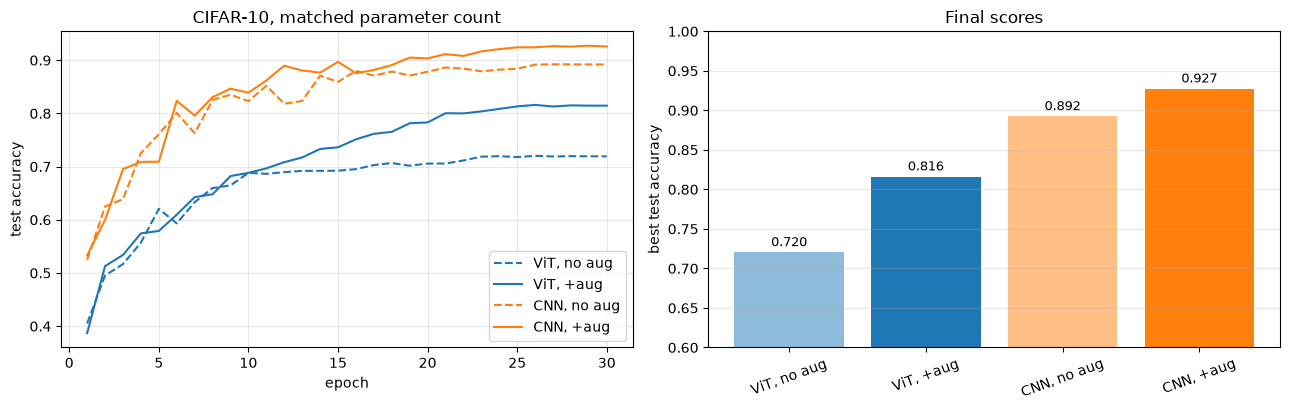

                 no aug     +aug     gain
ViT              0.7202   0.8160  +0.0958
CNN              0.8923   0.9273  +0.0350

CNN beats ViT by 0.111 with augmentation, 0.172 without.
Augmentation is worth 2.7x more to the ViT than to the CNN.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

styles = {"ViT, no aug": ("tab:blue", "--"), "ViT, +aug": ("tab:blue", "-"),
          "CNN, no aug": ("tab:orange", "--"), "CNN, +aug": ("tab:orange", "-")}
for name, accs in results.items():
    col, ls = styles[name]
    axes[0].plot(range(1, len(accs) + 1), accs, color=col, ls=ls, label=name)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("test accuracy")
axes[0].set_title("CIFAR-10, matched parameter count")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

best = {k: max(v) for k, v in results.items()}
labels = ["ViT, no aug", "ViT, +aug", "CNN, no aug", "CNN, +aug"]
bar_colors = [(0.12, 0.47, 0.71, 0.5), (0.12, 0.47, 0.71, 1.0),      # ViT: pale, solid
              (1.00, 0.50, 0.05, 0.5), (1.00, 0.50, 0.05, 1.0)]      # CNN: pale, solid
axes[1].bar(range(4), [best[k] for k in labels], color=bar_colors)
axes[1].set_xticks(range(4)); axes[1].set_xticklabels(labels, rotation=20)
axes[1].set_ylabel("best test accuracy"); axes[1].set_ylim(0.6, 1.0)
axes[1].set_title("Final scores")
axes[1].grid(True, axis="y", alpha=0.3)
for i, k in enumerate(labels):
    axes[1].text(i, best[k] + 0.008, f"{best[k]:.3f}", ha="center", fontsize=9)

plt.tight_layout(); plt.show()

vit_gain = best["ViT, +aug"] - best["ViT, no aug"]
cnn_gain = best["CNN, +aug"] - best["CNN, no aug"]

print(f"{'':14s}{'no aug':>9}{'+aug':>9}{'gain':>9}")
print(f"{'ViT':14s}{best['ViT, no aug']:>9.4f}{best['ViT, +aug']:>9.4f}{vit_gain:>+9.4f}")
print(f"{'CNN':14s}{best['CNN, no aug']:>9.4f}{best['CNN, +aug']:>9.4f}{cnn_gain:>+9.4f}")
print(f"\nCNN beats ViT by {best['CNN, +aug'] - best['ViT, +aug']:.3f} with augmentation, "
      f"{best['CNN, no aug'] - best['ViT, no aug']:.3f} without.")
if cnn_gain > 0.005 and vit_gain > 0:
    print(f"Augmentation is worth {vit_gain / cnn_gain:.1f}x more to the ViT than to the CNN.")
else:
    print("(Augmentation gains are too small to form a stable ratio, most likely "
          "because EPOCHS was lowered. Run the full 30 to see the asymmetry.)")

## 4.1 Reading the result

**Both predictions held.**

**The CNN won comfortably**, at matched parameter count, on both halves of the
experiment. On 50,000 images the convolution's built-in assumptions about
locality and translation are simply worth more than the Transformer's freedom to
learn arbitrary relationships. Nothing is wrong with the ViT implementation, and
Module 5 will show it learned a great deal. The problem is that the ViT spent
capacity rediscovering facts about images that the CNN was born knowing.

**And the augmentation asymmetry is the mechanism, caught in the act.** Random
flips and crops are a way of *stating an invariance through examples*: "this
label does not change when the content moves or mirrors". The CNN already
implements translation equivariance in its wiring, so being told again is worth
comparatively little. The ViT has no such wiring, so the same augmentations are
worth several times more to it, since they are how it learns what convolution
hardcodes.

That ratio is the clearest single number in this notebook. It is the price of
generality, measured.

**So why did the field move to ViTs at all?** Because the trade reverses at
scale. Inductive bias is a *prior*, and priors help most when data is scarce and
constrain most when data is plentiful. Past roughly 100M images the CNN's
assumptions stop being helpful shortcuts and start being restrictions, while the
ViT, having enough data to learn better-than-hand-designed relationships,
overtakes it and keeps scaling. Everything you have read about "scaling laws"
in vision lives on that crossover.

Three practical consequences worth carrying:

- **Nobody trains a ViT from scratch on small data.** They fine-tune one
  pre-trained on ImageNet-21k or LAION. The beans fine-tuning you did in
  Chapter 4 is precisely the right instinct, applied to a different backbone.
- **Hybrid architectures** (Swin, ConvNeXt, CoAtNet) deliberately reintroduce
  locality and hierarchy into Transformers, to get some inductive bias back
  without giving up scaling.
- **A diffusion Transformer escapes this trap**, and it is worth understanding
  why before Chapter 12 builds one. A diffusion model's training signal is
  *per-patch noise prediction* on millions of noisy variants of every image, an
  enormously richer signal than one class label per image. Data scarcity is not
  the binding constraint there, which is exactly why DiTs beat U-Nets at moderate
  scale while ViTs need 300M images to beat ResNets.


---
# Module 5 — What Did It Actually Learn?

## 5.1 The positional embeddings rediscover 2-D space

🧠 **The intuition.** This is the most striking single result in the ViT paper,
and it reproduces on CIFAR-10 in 30 epochs.

Recall what the model was given: 65 position vectors, initialized as random
noise, indexed 0 to 64. **It was never told the patches form a grid.** Nothing in
the architecture encodes that patch 9 sits directly below patch 1, or that
patches 8 and 9 are side by side. Those are facts about the world that only exist
in the data.

If the model discovered the 2-D layout anyway, the learned position vectors
should be most similar to their **spatial** neighbours. And the sharp test is the
vertical one: patch $i$ and patch $i{+}8$ are adjacent *on the image* but eight
apart *in the sequence*. A model with only a vague 1-D sense of position would
show similarity decaying smoothly with index distance. A model that understands
the grid must show a **bump at offset 8**.

💻 **The code.**

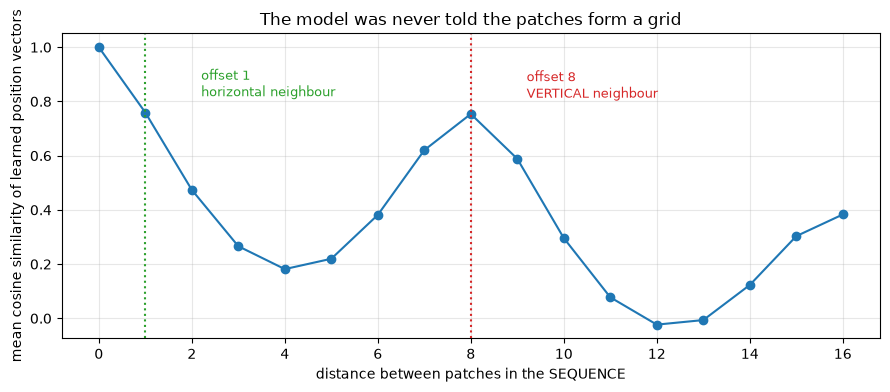

similarity at offset 1  (horizontal neighbour): +0.759
similarity at offset 4  (halfway across a row) : +0.182   <- trough
similarity at offset 8  (vertical neighbour)  : +0.754   <- rebound

The rebound is +0.572 above the trough.
A purely 1-D sense of position would decay monotonically and never come back.


In [11]:
pos = vit_aug.pos_embed.detach()[0, 1:]                       # drop the [CLS] slot -> (64, d)
pos = pos / pos.norm(dim=-1, keepdim=True)
sim = (pos @ pos.T).cpu().numpy()                             # cosine similarity, (64, 64)

offsets = np.arange(0, 17)
mean_sim = [np.mean([sim[i, i + o] for i in range(N_PATCHES - o)]) for o in offsets]

plt.figure(figsize=(9, 4))
plt.plot(offsets, mean_sim, marker="o")
plt.axvline(1, color="tab:green", ls=":", lw=1.5)
plt.axvline(GRID, color="tab:red", ls=":", lw=1.5)
plt.annotate("offset 1\nhorizontal neighbour", (1, mean_sim[1]),
             xytext=(2.2, mean_sim[1] + 0.06), fontsize=9, color="tab:green")
plt.annotate(f"offset {GRID}\nVERTICAL neighbour", (GRID, mean_sim[GRID]),
             xytext=(GRID + 1.2, mean_sim[GRID] + 0.06), fontsize=9, color="tab:red")
plt.xlabel("distance between patches in the SEQUENCE")
plt.ylabel("mean cosine similarity of learned position vectors")
plt.title("The model was never told the patches form a grid")
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

trough = int(np.argmin(mean_sim[1:GRID])) + 1
print(f"similarity at offset 1  (horizontal neighbour): {mean_sim[1]:+.3f}")
print(f"similarity at offset {trough}  (halfway across a row) : {mean_sim[trough]:+.3f}   <- trough")
print(f"similarity at offset {GRID}  (vertical neighbour)  : {mean_sim[GRID]:+.3f}   <- rebound")
print(f"\nThe rebound is {mean_sim[GRID] - mean_sim[trough]:+.3f} above the trough.")
print("A purely 1-D sense of position would decay monotonically and never come back.")

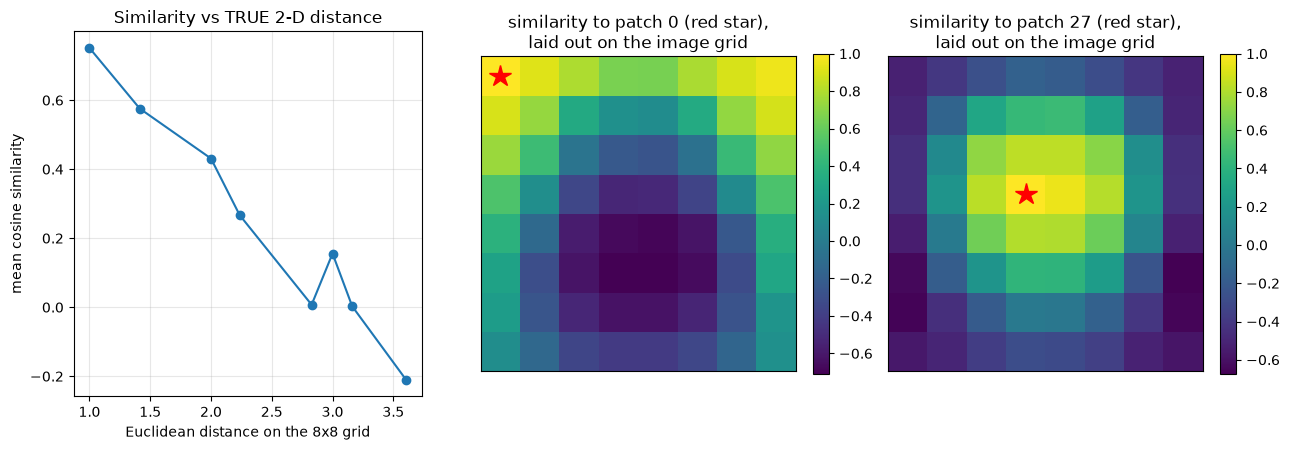

correlation(cosine similarity, 2-D grid distance) = -0.461

The two right-hand panels are the payoff: a bright blob centred exactly on
the chosen patch, fading outward in 2-D. The model reconstructed the spatial
layout of the image from nothing but 50,000 labelled examples.


In [12]:
row, col = np.arange(N_PATCHES) // GRID, np.arange(N_PATCHES) % GRID
grid_dist = np.sqrt((row[:, None] - row[None, :]) ** 2 + (col[:, None] - col[None, :]) ** 2)

fig = plt.figure(figsize=(13, 4.6))

ax = fig.add_subplot(1, 3, 1)
buckets = sorted({round(d, 3) for d in grid_dist.flatten() if d > 0})[:8]
ax.plot(buckets, [sim[np.abs(grid_dist - b) < 1e-3].mean() for b in buckets], marker="o")
ax.set_xlabel("Euclidean distance on the 8x8 grid"); ax.set_ylabel("mean cosine similarity")
ax.set_title("Similarity vs TRUE 2-D distance")
ax.grid(True, alpha=0.3)

for k, p in enumerate([0, 27]):
    ax = fig.add_subplot(1, 3, k + 2)
    im = ax.imshow(sim[p].reshape(GRID, GRID), cmap="viridis")
    ax.plot(p % GRID, p // GRID, "r*", markersize=16)
    ax.set_title(f"similarity to patch {p} (red star),\nlaid out on the image grid")
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout(); plt.show()

mask = ~np.eye(N_PATCHES, dtype=bool)
print(f"correlation(cosine similarity, 2-D grid distance) = "
      f"{np.corrcoef(sim[mask], grid_dist[mask])[0, 1]:+.3f}")
print("\nThe two right-hand panels are the payoff: a bright blob centred exactly on")
print("the chosen patch, fading outward in 2-D. The model reconstructed the spatial")
print("layout of the image from nothing but 50,000 labelled examples.")

## 5.2 How far does each head look?

🧠 **The intuition.** A CNN's receptive field is a fact about its architecture:
layer 1 sees 3×3, and there is no arguing with it. A ViT's is a fact about its
*weights*, since every layer *could* attend globally, and whether it does is
learned.

So we can ask a question that has no CNN equivalent: **how far does each head
actually look?** Weight the 2-D distance between patches by the attention paid,
and average. Small numbers mean the head has taught itself to behave like a
convolution; large numbers mean it is spreading attention across the whole image.

📐 **Set the two reference points before looking**, or the number is
uninterpretable:

- A head that behaves like a **3×3 convolution**, attending only to its
  immediate neighbours, scores about **1.0** patch.
- A head attending **completely uniformly**, paying equal attention everywhere,
  scores the mean pairwise distance on the grid, which for 8×8 is about
  **4.14** patches. This is the "no preference at all" baseline.

The ViT paper reports that in a well-trained model some heads sit near the
bottom of that range (learned locality) and others near the top, with the
average rising through depth. Let us see what ours did.


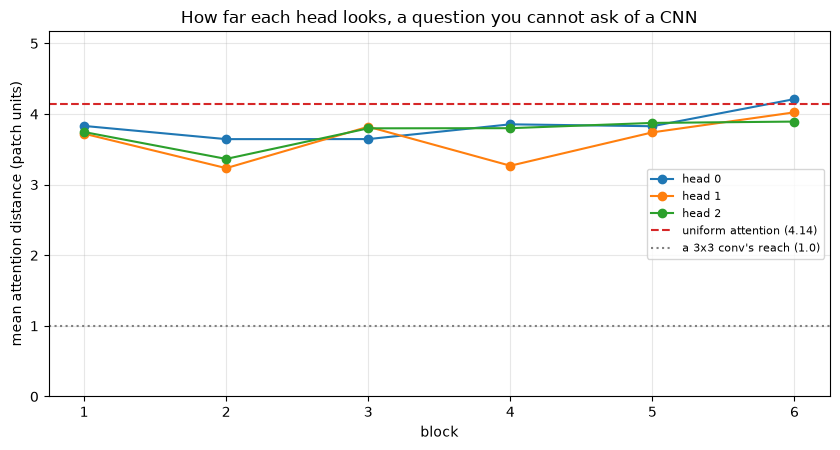

uniform-attention baseline: 4.14 patches
a 3x3-convolution-like head: ~1.0 patches

block 1: heads reach 3.72 to 3.83
block 6: heads reach 3.89 to 4.21

largest deviation of any head from the uniform baseline: 0.90 patches
distance from the uniform baseline down to conv-like:     3.14 patches
-> every head is 3.5x closer to 'no spatial preference' than to 'local'


In [13]:
vit_aug.eval()
with torch.no_grad():
    _, maps = vit_aug(X_test[:256].to(device))

dist_t = torch.tensor(grid_dist, dtype=torch.float32, device=device)
attn_distance = []
for A in maps:
    patch_attn = A[:, :, 1:, 1:]                                   # drop [CLS] row and column
    patch_attn = patch_attn / patch_attn.sum(-1, keepdim=True).clamp(min=1e-9)
    attn_distance.append((patch_attn * dist_t).sum(-1).mean(dim=(0, 2)).cpu().numpy())

attn_distance = np.array(attn_distance)                            # (depth, heads)

uniform_baseline = grid_dist.mean()          # what "attend to everything equally" scores

plt.figure(figsize=(8.5, 4.6))
for h in range(attn_distance.shape[1]):
    plt.plot(range(1, len(maps) + 1), attn_distance[:, h], marker="o", label=f"head {h}")
plt.axhline(uniform_baseline, color="tab:red", ls="--",
            label=f"uniform attention ({uniform_baseline:.2f})")
plt.axhline(1.0, color="gray", ls=":", label="a 3x3 conv's reach (1.0)")
plt.ylim(0, uniform_baseline * 1.25)
plt.xlabel("block"); plt.ylabel("mean attention distance (patch units)")
plt.title("How far each head looks, a question you cannot ask of a CNN")
plt.legend(fontsize=8); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"uniform-attention baseline: {uniform_baseline:.2f} patches")
print(f"a 3x3-convolution-like head: ~1.0 patches\n")
print(f"block 1: heads reach {attn_distance[0].min():.2f} to {attn_distance[0].max():.2f}")
print(f"block {len(maps)}: heads reach {attn_distance[-1].min():.2f} to {attn_distance[-1].max():.2f}")

worst = np.abs(attn_distance - uniform_baseline).max()
print(f"\nlargest deviation of any head from the uniform baseline: {worst:.2f} patches")
print(f"distance from the uniform baseline down to conv-like:     {uniform_baseline - 1.0:.2f} patches")
print(f"-> every head is {(uniform_baseline - 1.0) / worst:.1f}x closer to 'no spatial "
      f"preference' than to 'local'")

### This is not the picture the ViT paper shows, and that is the finding

**Every head, in every block, sits close to the uniform-attention baseline**:
the largest deviation printed above is under one patch, against a **3.1-patch**
gap down to convolution-like behaviour. In other words every head is several
times nearer to "no spatial preference at all" than to "local". Not one learned
to be local, and the lines are flat across depth because there is nothing to
increase *from*: attention started diffuse and stayed diffuse.

**And this is the mechanism behind Module 4's result, caught directly.** The
argument there was that a ViT must *learn* locality from data while a CNN is born
with it. Module 4 measured the consequence: the CNN won, and augmentation was worth
roughly three times more to the ViT. This plot measures the cause: on 50,000 images, the
ViT **never discovered locality at all**.

Note the contrast with 5.1, which is what makes this interesting rather than
merely disappointing. The *positional embeddings* learned the 2-D grid
beautifully, and the model absolutely knows which patches are neighbours. It
simply never learned that neighbours are the ones worth attending to. Knowing
the geometry and exploiting it are separate problems, and 50,000 labelled images
was enough for the first but not the second.

This is also a falsifiable prediction you can check yourself: a ViT pre-trained
on ImageNet-21k, run through this same measurement, shows exactly the spread of
local and global heads the paper describes.


## 5.3 Where does `[CLS]` look?

💻 The `[CLS]` token's attention row in the final block is a free saliency map:
it shows which patches the classifier actually drew from. Reshape those 64
weights back onto the image grid.

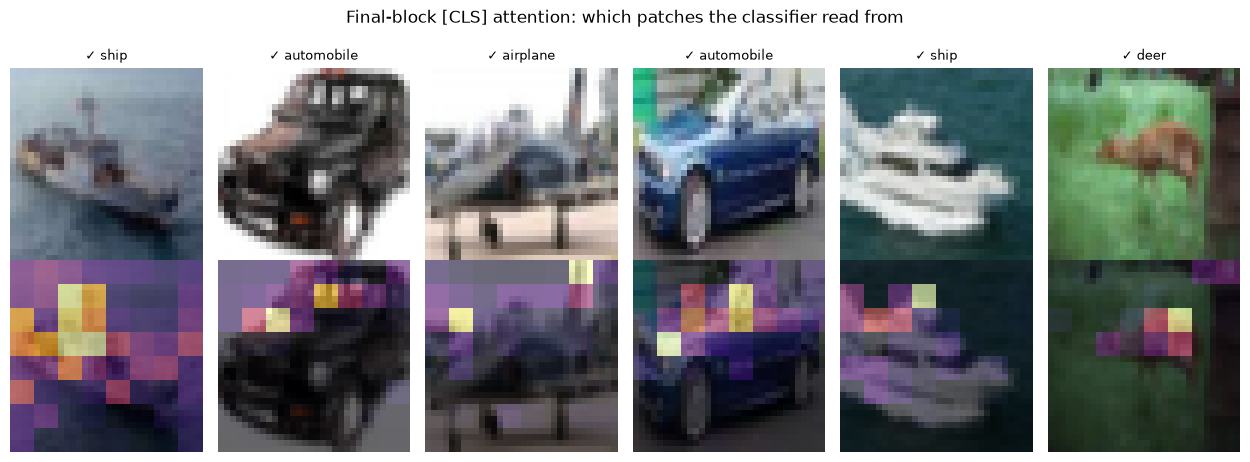

Bright = heavily attended. Expect the object, not the background,
though see Chapter 9's caution: attention shows where information flowed,
not why the decision was made.


In [14]:
n_show = 6
idx = torch.arange(n_show) * 37

with torch.no_grad():
    logits, maps = vit_aug(X_test[idx].to(device))
pred = logits.argmax(-1).cpu()

cls_attn = maps[-1][:, :, 0, 1:].mean(1).cpu().numpy()             # (n, 64), averaged over heads

fig, axes = plt.subplots(2, n_show, figsize=(2.1 * n_show, 4.6))
for k in range(n_show):
    img = (X_test[idx[k]] * STD[0] + MEAN[0]).permute(1, 2, 0).numpy().clip(0, 1)
    axes[0, k].imshow(img)
    ok = "✓" if pred[k] == y_test[idx[k]] else "✗"
    axes[0, k].set_title(f"{ok} {class_names[pred[k]]}", fontsize=9)
    axes[0, k].axis("off")

    heat = cls_attn[k].reshape(GRID, GRID)
    axes[1, k].imshow(img)
    axes[1, k].imshow(np.kron(heat, np.ones((PATCH, PATCH))), cmap="inferno", alpha=0.6)
    axes[1, k].axis("off")

axes[0, 0].set_ylabel("image"); axes[1, 0].set_ylabel("[CLS] attention")
fig.suptitle("Final-block [CLS] attention: which patches the classifier read from", y=1.0)
plt.tight_layout(); plt.show()

print("Bright = heavily attended. Expect the object, not the background,")
print("though see Chapter 9's caution: attention shows where information flowed,")
print("not why the decision was made.")

---
# Wrap-Up

| You built | The transferable lesson |
|---|---|
| Patch embedding | An image becomes a sequence by cutting it into a grid; $P{=}4$ on CIFAR turns 1,024 pixel-tokens into 64, cutting the attention matrix 256× |
| The `Conv2d(k=P, stride=P)` identity | A non-overlapping convolution *is* a linear projection of flattened patches, proved by weight-sharing rather than asserted |
| `[CLS]` token | Learned, content-dependent pooling; and a free saliency map |
| Learnable positional embeddings | Random vectors that **rediscovered the 2-D grid**, and the rebound at offset 8 is the proof |
| The 2×2 inductive-bias experiment | The CNN wins at 50k images with matched parameters, and augmentation is worth several times more to the ViT. Generality costs data |
| Mean attention distance | A ViT's receptive field is learned rather than architectural, and ours **never learned locality**, sitting at the uniform baseline in every head. The direct cause of the Module 4 result |

**The honest summary of Vision Transformers.** They are not a better image
architecture than CNNs; they are a *more general* one. Below ~100M images that
generality is a liability, and everything you measured in Module 4 says so. Above
it, the ordering flips and keeps flipping in the ViT's favour, which is why
essentially every frontier vision model is now Transformer-based, and essentially
every one of them is pre-trained on data you and I do not have.

**Chapter 12 changes the task, and the calculus with it.** It keeps the patch
embedding, keeps the positional embeddings, keeps the block, and swaps the
target. Instead of one class label per image, the model predicts **the noise
added to every patch**, at every one of hundreds of timestep levels. That is a
vastly denser training signal from the same 50,000 images, and it is why the data
scarcity that hobbled our ViT will not hobble a DiT.

One thing does change inside the block. The timestep and class conditioning have
to get in somewhere, and the answer is the one flagged at the end of Chapter 10:
$\gamma$ and $\beta$ in LayerNorm stop being free parameters and start being
**predicted from the conditioning**. That is **adaptive LayerNorm**, it is the
central idea of the Diffusion Transformer, and it replaces the U-Net you built in
Chapter 8 with the architecture behind Stable Diffusion 3, Flux, and Sora.
